In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

from tensorflow.python.client import device_lib

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

['/device:CPU:0']


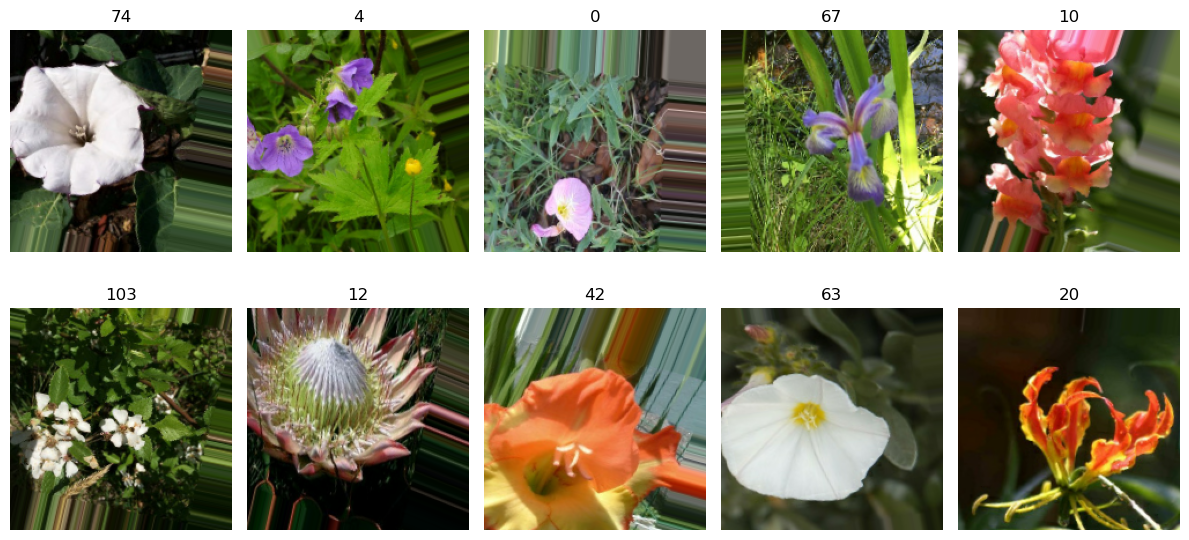

Training Set - Class: 0, Count: 272
Training Set - Class: 1, Count: 26
Training Set - Class: 10, Count: 136
Training Set - Class: 100, Count: 31
Training Set - Class: 101, Count: 25
Training Set - Class: 102, Count: 390
Training Set - Class: 103, Count: 743
Training Set - Class: 11, Count: 43
Training Set - Class: 12, Count: 92
Training Set - Class: 13, Count: 263
Training Set - Class: 14, Count: 227
Training Set - Class: 15, Count: 21
Training Set - Class: 16, Count: 55
Training Set - Class: 17, Count: 50
Training Set - Class: 18, Count: 90
Training Set - Class: 19, Count: 26
Training Set - Class: 2, Count: 20
Training Set - Class: 20, Count: 19
Training Set - Class: 21, Count: 96
Training Set - Class: 22, Count: 48
Training Set - Class: 23, Count: 19
Training Set - Class: 24, Count: 85
Training Set - Class: 25, Count: 83
Training Set - Class: 26, Count: 21
Training Set - Class: 27, Count: 34
Training Set - Class: 28, Count: 119
Training Set - Class: 29, Count: 109
Training Set - Clas

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

def load_dataset(dataset_dir):
    """
    Load the image dataset from the specified directory.
    
    Args:
        dataset_dir (str): Path to the dataset directory.
    
    Returns:
        images (list): List of image data as NumPy arrays.
        labels (list): List of corresponding labels.
    """
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_dir))
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_dir, class_name)
        image_files = os.listdir(class_dir)
        
        for image_file in image_files:
            image_path = os.path.join(class_dir, image_file)
            image = Image.open(image_path)
            images.append(np.array(image))
            labels.append(class_name)
    
    return images, labels

def visualize_images(images, labels):
    """
    Display a random selection of images from the dataset along with their labels.
    
    Args:
        images (list): List of image data as NumPy arrays.
        labels (list): List of corresponding labels.
    """
    num_images = len(images)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    
    for i, ax in enumerate(axes.flatten()):
        random_index = np.random.randint(num_images)
        image = images[random_index]
        label = labels[random_index]
        
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(label)
    
    plt.tight_layout()
    plt.show()


# Specify the path to your dataset directory
dataset_dir = 'Data'

# Load the dataset
train_images, train_labels = load_dataset(os.path.join(dataset_dir, 'train'))
test_images, test_labels = load_dataset(os.path.join(dataset_dir, 'test'))

# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Scale pixel values between 0 and 1
    rotation_range=20,  # Randomly rotate images by 20 degrees
    width_shift_range=0.2,  # Randomly shift images horizontally by 20% of the width
    height_shift_range=0.2,  # Randomly shift images vertically by 20% of the height
    shear_range=0.2,  # Randomly apply shearing transformations
    zoom_range=0.2,  # Randomly zoom-in on images
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest'  # Fill any newly created pixels during augmentation with the nearest pixel value
)

# No augmentation for test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Split the training data into training and validation sets
train_val_ratio = 0.9
train_val_index = int(len(train_images) * train_val_ratio)

train_data = train_images[:train_val_index]
train_labels = train_labels[:train_val_index]
val_data = train_images[train_val_index:]
val_labels = train_labels[train_val_index:]

train_data = np.array(train_data[:train_val_index])
train_labels = np.array(train_labels[:train_val_index])
val_data = np.array(train_data[train_val_index:])
val_labels = np.array(train_labels[train_val_index:])

# Prepare the augmented training data generator
train_generator = train_datagen.flow(
    train_data, train_labels, batch_size=32
)

# Prepare the validation data generator
val_generator = test_datagen.flow(
    val_data, val_labels, batch_size=32
)

# Visualize some augmented images from the training set
augmented_images, augmented_labels = train_generator.next()
visualize_images(augmented_images, augmented_labels)

# Display class counts for the training set
unique_train_classes, train_counts = np.unique(train_labels, return_counts=True)

for class_name, count in zip(unique_train_classes, train_counts):
    print(f"Training Set - Class: {class_name}, Count: {count}")

# Display class counts for the validation set
unique_val_classes, val_counts = np.unique(val_labels, return_counts=True)

for class_name, count in zip(unique_val_classes, val_counts):
    print(f"Validation Set - Class: {class_name}, Count: {count}")

# Model training code (using train_generator and val_generator for training and validation)

# Model evaluation using the test data
#test_predictions = model.predict(test_images)
# ...perform evaluation and metrics calculation using test_predictions and test_labels...


## Build cnn


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the model
model = Sequential()

# Add convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(192, 192, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the output
model.add(Flatten())

# Add a fully connected layer
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(104, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 190, 190, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 95, 95, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 93, 93, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 46, 46, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 135424)            0         
                                                                 
 dense (Dense)               (None, 64)                8

In [5]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[]

In [6]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the training labels
train_labels_one_hot = to_categorical(train_labels, num_classes=104)

# One-hot encode the validation labels
val_labels_one_hot = to_categorical(val_labels, num_classes=104)
# Define the number of epochs and the batch size
epochs = 5
batch_size = 32

# Convert the validation labels to one-hot encoding
val_labels_one_hot = to_categorical(val_labels, num_classes=104)

# Train and validate the model
for epoch in range(epochs):
    history = model.fit(
        train_data,
        train_labels_one_hot,
        validation_data=(val_data, val_labels_one_hot),
        epochs=1,
        batch_size=batch_size
    )

    # Save the model after each epoch
    model.save(f'model_epoch_{epoch+1}.h5')


359/359 [==============================] - 303s 843ms/step - loss: 1.3463 - accuracy: 0.6293


In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Load the pre-trained VGG16 model
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(192, 192, 3))

# Freeze the layers of the pre-trained model
for layer in vgg_model.layers:
    layer.trainable = False

# Add custom fully connected layers on top of the pre-trained model
x = Flatten()(vgg_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(104, activation='softmax')(x)

# Create the final VGG model
model = Model(inputs=vgg_model.input, outputs=x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 192, 192, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 192, 192, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 192, 192, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 96, 96, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 96, 96, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 96, 96, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 48, 48, 128)       0     

In [8]:
# Define the number of epochs and the batch size
epochs = 10
batch_size = 32

# Train and validate the VGG model
for epoch in range(epochs):
    history = model.fit(
        train_data,
        train_labels_one_hot,
        validation_data=(val_data, val_labels_one_hot),
        epochs=1,
        batch_size=batch_size
    )


359/359 [==============================] - 1405s 4s/step - loss: 4.5436 - accuracy: 0.2375
